In [506]:
def plot_acceleration(csv_file):
    """
    Loads a CSV file and plots acceleration signals (X, Y, Z) over time.
    
    Parameters:
    csv_file (str): Path to the CSV file containing acceleration data.
    """
   
    df = pd.read_csv(csv_file)
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Plot acceleration for each axis
    axes[0].plot(df["Time (s)"], df["Acceleration x (m/s^2)"], label="X-axis", color='blue')
    axes[0].set_ylabel("Acceleration (m/s²)")
    axes[0].set_title("Acceleration X")
    axes[0].legend()

    axes[1].plot(df["Time (s)"], df["Acceleration y (m/s^2)"], label="Y-axis", color='green')
    axes[1].set_ylabel("Acceleration (m/s²)")
    axes[1].set_title("Acceleration Y")
    axes[1].legend()

    axes[2].plot(df["Time (s)"], df["Acceleration z (m/s^2)"], label="Z-axis", color='red')
    axes[2].set_ylabel("Acceleration (m/s²)")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Acceleration Z")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

In [507]:
import os

def remove_gravity_and_save(csv_file):
    """
    Loads a CSV file, removes gravitational acceleration (flat surface assumption),
    and saves the corrected data while keeping all original columns.
    
    Parameters:
    csv_file (str): Path to the input CSV file.
    
    Returns:
    str: Path to the new CSV file with gravity removed.
    """
    # Load CSV file and normalize column names (strip spaces)
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip()  # Remove leading/trailing spaces

    # Check available column names
    expected_columns = ["Time (s)", "Acceleration x (m/s^2)", "Acceleration y (m/s^2)", 
                        "Acceleration z (m/s^2)", "Absolute acceleration (m/s^2)"]
    
    missing_columns = [col for col in expected_columns if col not in df.columns]
    if missing_columns:
        print(f"ERROR: Missing columns in CSV file: {missing_columns}")
        print(f"Available columns: {list(df.columns)}")
        return None

    # Apply gravity correction only to the z-axis
    df["Acceleration z (m/s^2)"] = df["Acceleration z (m/s^2)"] - 9.81  

    # Generate new filename
    base_name = os.path.splitext(csv_file)[0]  # Remove ".csv" from filename
    new_filename = f"{base_name}_no_gravity.csv"

    # Save the corrected data with the same structure
    df.to_csv(new_filename, index=False, float_format="%.10f")

    print(f"Gravity-corrected data saved as: {new_filename}")
    return new_filename

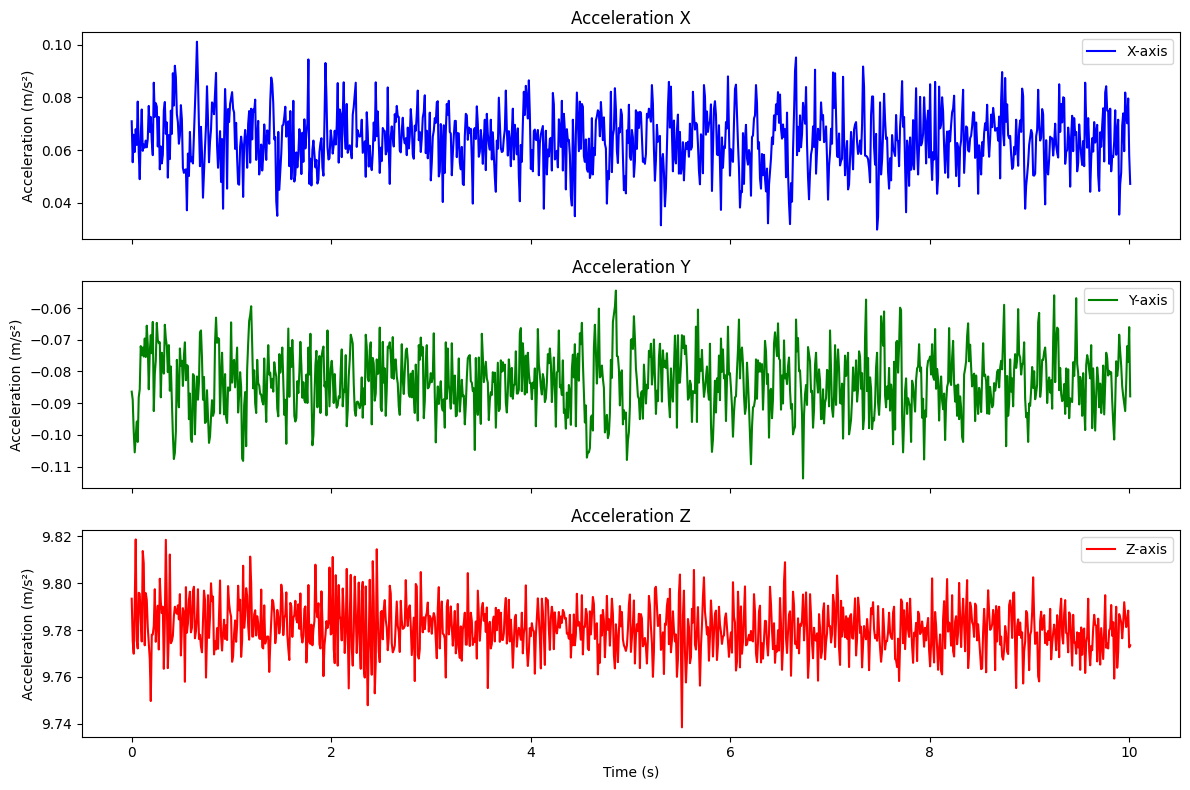

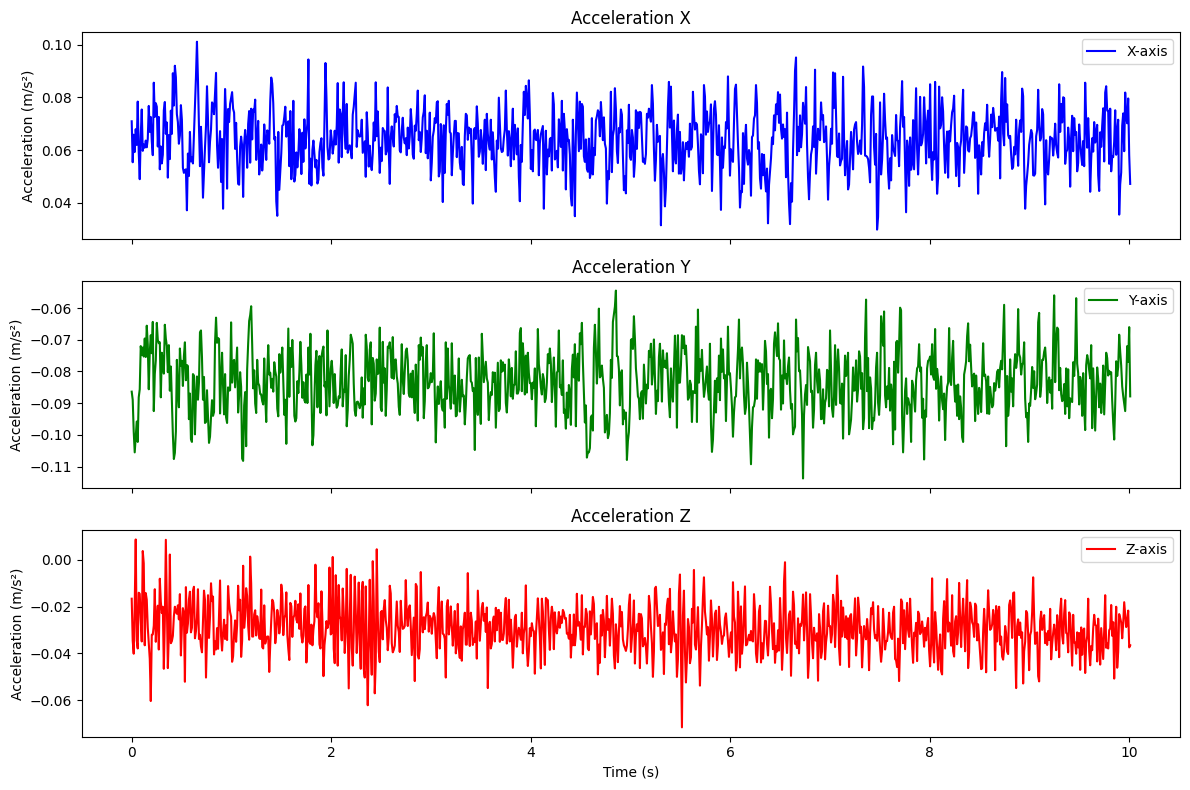

In [508]:
plot_acceleration("static_data_collection.csv")
plot_acceleration("static_data_collection_no_gravity.csv")

In [509]:
import pandas as pd

def load_acceleration_data_from_csv(filepath):
    """
    Liest eine CSV-Datei im Format:
    Time (s),Acceleration x/y/z (m/s^2),Absolute acceleration (m/s^2)
    
    Gibt ein N x 4 Array zurück: [Index, ax, ay, az]
    """
    df = pd.read_csv(filepath)

    # N x 4 Array: Spalte 0 = Index, Spalten 1-3 = ax, ay, az
    acc = np.zeros((len(df), 4))
    acc[:, 0] = np.arange(len(df))  # Index-Spalte
    acc[:, 1] = df.iloc[:, 1]       # Acceleration x
    acc[:, 2] = df.iloc[:, 2]       # Acceleration y
    acc[:, 3] = df.iloc[:, 3]       # Acceleration z

    return acc, df["Time (s)"].values

In [510]:
import numpy as np
from scipy.fft import fft, fftfreq

def plot_acceleration_spectrum(accel_data, fs, combine_axes=False):
    """
    Plots the frequency spectrum (in dB) of acceleration data.

    Parameters:
    - accel_data: ndarray of shape (N, 3) -> acceleration in x, y, z axes
    - fs: Sampling frequency in Hz
    - combine_axes: if True, uses the vector magnitude before FFT
    """
    N = accel_data.shape[0]
    freqs = fftfreq(N, 1/fs)[:N//2]

    plt.figure(figsize=(12, 6))

    if combine_axes:
        acc_mag = np.linalg.norm(accel_data, axis=1)
        spectrum = np.abs(fft(acc_mag))[:N//2]
        spectrum_db = 20 * np.log10(spectrum + 1e-12)  # avoid log(0)
        plt.plot(freqs, spectrum_db, label='Combined magnitude', color='black')
    else:
        for i, axis in enumerate(['X', 'Y', 'Z']):
            signal = accel_data[:, i]
            spectrum = np.abs(fft(signal))[:N//2]
            spectrum_db = 20 * np.log10(spectrum + 1e-12)  # dB scale
            plt.plot(freqs, spectrum_db, label=f'{axis}-Axis')

    plt.title('Acceleration Frequency Spectrum (in dB)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (dB)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

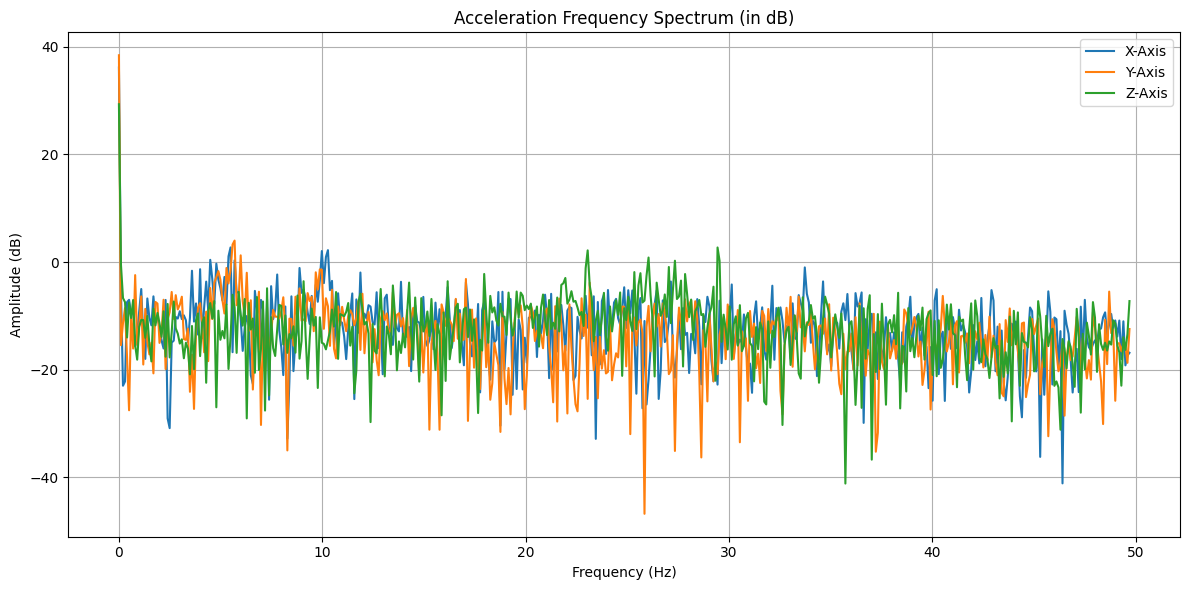

In [511]:
acc, time = load_acceleration_data_from_csv("static_data_collection_no_gravity.csv")
fs = 1 / np.mean(np.diff(time))

acc_data, time = load_acceleration_data_from_csv("static_data_collection_no_gravity.csv")
fs = 1 / np.mean(np.diff(time))  # Sampling rate

plot_acceleration_spectrum(acc[:, 1:4], fs, combine_axes=False)  # Einzelachsen

In [512]:
from scipy.signal import lfilter, butter, filtfilt, savgol_filter

def calculate_trajectory(acceleration, fs, v0, p0, filtering=None):
    """
    Parameters:
        acceleration : np.array -> shape (N, 4) with [t, ax, ay, az]
        fs           : float    -> sampling frequency
        v0           : list     -> initial velocity [vx0, vy0, vz0]
        p0           : list     -> initial position [px0, py0, pz0]
        filtering    : str or None -> options: None, 'savgol', 'bandpass', 'lowpass'

    Returns:
        position : ndarray of shape (N, 3)
        velocity : ndarray of shape (N, 3)
    """

    b = [1]
    a = [1, -1]

    # Optional Z-removal if only XY movement
    # acceleration[:, 3] = 0.0

    # Apply filtering
    if filtering == "savgol":
        for i in range(1, 4):
            acceleration[:, i] = savgol_filter(acceleration[:, i], 201, 3)

    elif filtering == "bandpass":
        lowcut = 0.3
        highcut = 4.0
        order = 4
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b_band, a_band = butter(order, [low, high], btype='band')
        for i in range(1, 4):
            acceleration[:, i] = filtfilt(b_band, a_band, acceleration[:, i])

    elif filtering == "lowpass":
        cutoff = 1.0
        order = 4
        nyq = 0.5 * fs
        norm_cutoff = cutoff / nyq
        b_lp, a_lp = butter(order, norm_cutoff, btype='low')
        for i in range(1, 4):
            acceleration[:, i] = filtfilt(b_lp, a_lp, acceleration[:, i])
    
    elif filtering == "none" or filtering is None:
        pass  # no filtering
    else:
        raise ValueError(f"Unknown filtering method: {filtering}")

    # Remove mean offset (bias)
    acceleration[:, 1:4] -= np.mean(acceleration[:, 1:4], axis=0)

    dt = 1 / fs

    # First integration → velocity
    vx = lfilter(b, a, acceleration[:, 1]) * dt + v0[0]
    vy = lfilter(b, a, acceleration[:, 2]) * dt + v0[1]
    vz = lfilter(b, a, acceleration[:, 3]) * dt + v0[2]

    # Remove velocity drift
    vx -= np.mean(vx)
    vy -= np.mean(vy)
    vz -= np.mean(vz)

    # Second integration → position
    px = lfilter(b, a, vx) * dt + p0[0]
    py = lfilter(b, a, vy) * dt + p0[1]
    pz = lfilter(b, a, vz) * dt + p0[2]

    position = np.vstack([px, py, pz]).T
    velocity = np.vstack([vx, vy, vz]).T
    return position, velocity

In [513]:
def plot_trajectories(trajectories):
    """
    Plot multiple 3D trajectories and their top-down XY projections side by side.

    Parameters:
    - trajectories: list of tuples, where each tuple is (position_array, label)
        - position_array: ndarray of shape (N, 3), representing X, Y, Z
        - label: str, name to show in the legend (e.g., "Raw", "Filtered")
    """
    fig = plt.figure(figsize=(14, 6))

    # Left: 3D plot
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    for position, label in trajectories:
        x, y, z = position[:, 0], position[:, 1], position[:, 2]
        ax3d.plot(x, y, z, linewidth=1.5, label=label)
    ax3d.set_xlabel('X Position (m)', labelpad=12)
    ax3d.set_ylabel('Y Position (m)', labelpad=12)
    ax3d.set_zlabel('Z Position (m)', labelpad=18)  # <--- mehr Abstand!
    ax3d.set_title('3D Motion Trajectories')
    ax3d.set_box_aspect([1, 1, 1])
    ax3d.legend()
    ax3d.grid(True)

    # Right: Top-down XY view
    ax2d = fig.add_subplot(1, 2, 2)
    for position, label in trajectories:
        x, y = position[:, 0], position[:, 1]
        ax2d.plot(x, y, linewidth=1.5, label=label)
    ax2d.set_xlabel('X Position (m)')
    ax2d.set_ylabel('Y Position (m)')
    ax2d.set_title('Top-Down View (XY Plane)')
    ax2d.set_aspect('equal', adjustable='box')
    ax2d.legend()
    ax2d.grid(True)

    plt.tight_layout()
    plt.show()

In [514]:
import matplotlib.pyplot as plt
import numpy as np

def plot_velocity(velocities, fs, labels=None):
    """
    Plots Vx(t), Vy(t), Vz(t) over time for multiple velocity inputs.

    Parameters:
    - velocities: list of velocity arrays (N, 3) or list of (velocity_array, label)
    - fs: sampling frequency [Hz]
    - labels: optional list of labels if velocities is a list of raw arrays
    """
    if isinstance(velocities[0], tuple):
        velocity_sets = velocities
    else:
        if labels is None:
            labels = [f"Set {i+1}" for i in range(len(velocities))]
        velocity_sets = list(zip(velocities, labels))

    time = np.arange(velocity_sets[0][0].shape[0]) / fs

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].set_title("Velocity over Time")

    for velocity, label in velocity_sets:
        axes[0].plot(time, velocity[:, 0], label=label)
        axes[1].plot(time, velocity[:, 1], label=label)
        axes[2].plot(time, velocity[:, 2], label=label)

    axes[0].set_ylabel("Vx (m/s)")
    axes[1].set_ylabel("Vy (m/s)")
    axes[2].set_ylabel("Vz (m/s)")
    axes[2].set_xlabel("Time (s)")

    for ax in axes:
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

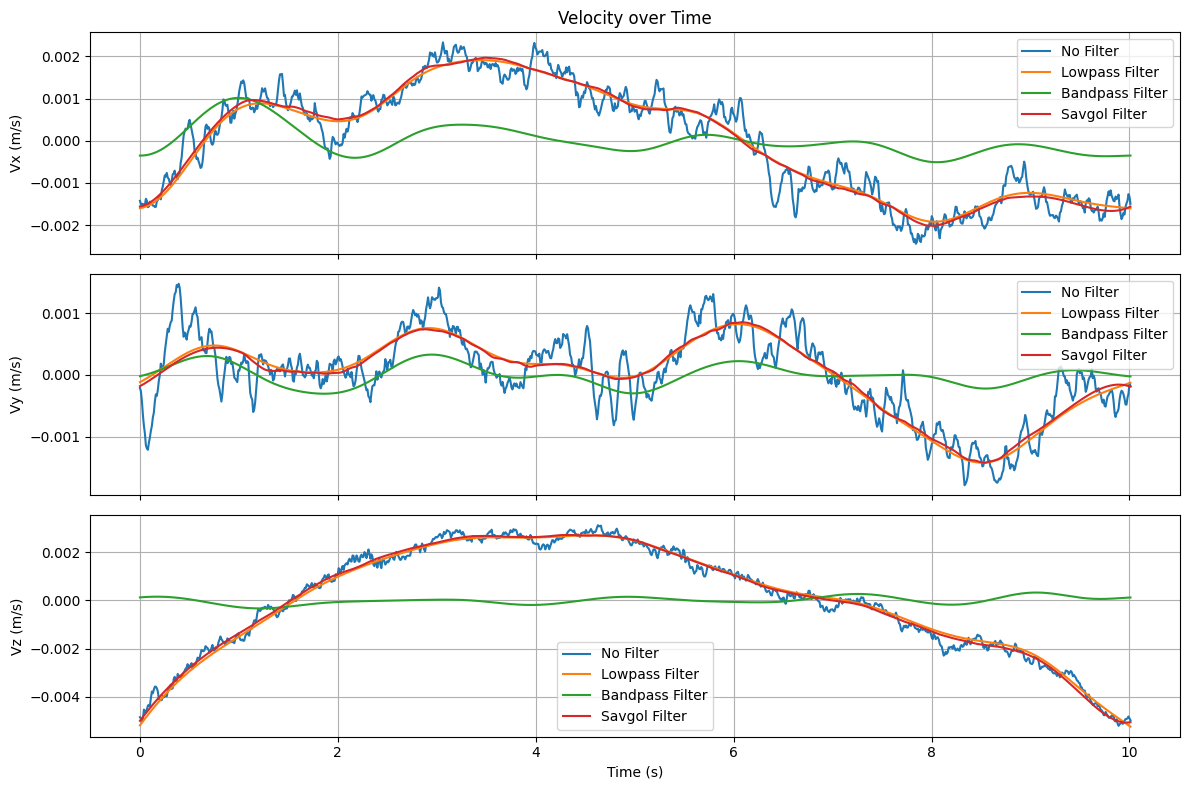

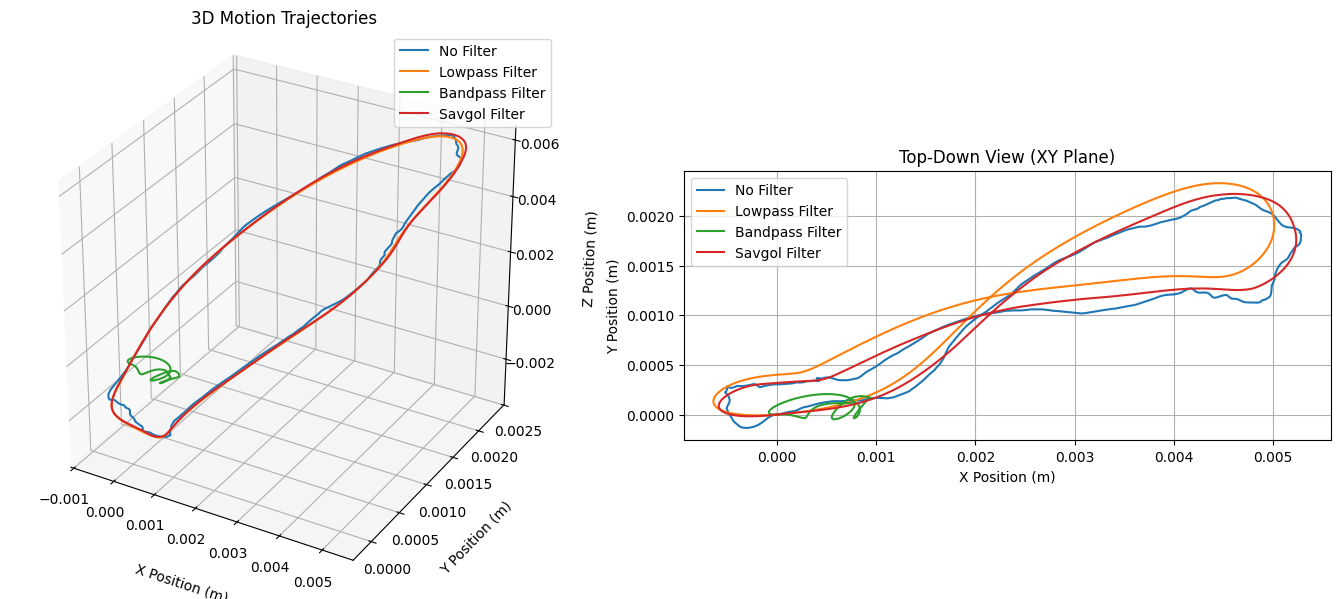

In [515]:
acc, time = load_acceleration_data_from_csv("static_data_collection_no_gravity.csv")
#acc, time = load_acceleration_data_from_csv("linear_movement_no_gravity.csv")
#acc, time = load_acceleration_data_from_csv("zig_zag_movement_no_gravity.csv")
fs = 1 / np.mean(np.diff(time))
trajectory_raw, velocity_raw= calculate_trajectory(acc, fs, v0=[0, 0, 0], p0=[0, 0, 0], filtering = "none")
trajectory_savgol, velocity_savgol = calculate_trajectory(acc, fs, v0=[0, 0, 0], p0=[0, 0, 0], filtering = "savgol")
trajectory_lowpass, velocity_lowpass = calculate_trajectory(acc, fs, v0=[0, 0, 0], p0=[0, 0, 0], filtering = "lowpass")
trajectory_bandpass, velocity_bandpass = calculate_trajectory(acc, fs, v0=[0, 0, 0], p0=[0, 0, 0], filtering = "bandpass")


plot_velocity(
    velocities=[
        (velocity_raw, "No Filter"),
        (velocity_lowpass, "Lowpass Filter"),
        (velocity_bandpass, "Bandpass Filter"),
        (velocity_savgol, "Savgol Filter")
    ],
    fs=fs
)

plot_trajectories([
    (trajectory_raw, "No Filter"),
    (trajectory_lowpass, "Lowpass Filter"),
    (trajectory_bandpass, "Bandpass Filter"),
    (trajectory_savgol, "Savgol Filter")
])